# Wiktor Zoga

In [43]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(2137)
np.random.seed(2137)

### Model

Podstawowe równanie modelu:
$$y = Wx + b$$

Zgodnie z poleceniem mamy 1D -> 1D, więc:
* $y, W, x, b \in \mathbb{R}$
* $m = 100$ (rozmiar batcha)

Razem z małym zaburzeniem model wygląda tak:
$$y = Wx + b + \varepsilon$$
gdzie $\varepsilon \sim \mathcal{N}(0, 0.1^2)$ (wariancje dobrałem według własnego uznania)

In [50]:
m = 100 # batch size

x = torch.rand(m)
y_real = 2 * x + 1

eps = torch.randn(m) * 0.1 # noise ~ N(0, 0.1^2)

y = y_real + eps # observed data

W = torch.randn(1) # random weight

b = torch.rand(1) # random bias

y_pred = W * x + b # predicted data from observed data

loss = torch.mean((y_pred - y) ** 2)

print(f"Loss: {loss.item()}")

Loss: 2.453559637069702


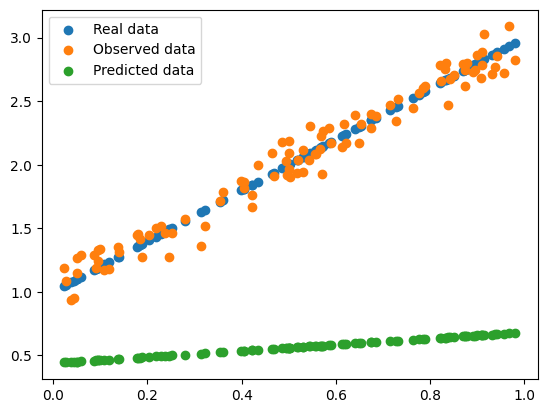

In [51]:
plt.scatter(x.numpy(), y_real.numpy(), label="Real data")
plt.scatter(x.numpy(), y.numpy(), label="Observed data")
plt.scatter(x.numpy(), y_pred.detach().numpy(), label="Predicted data")
plt.legend()
plt.show()

* What does the weight represent geometrically?  
    W jest współczynnikiem nachylenia prostej
* What does the bias represent?  
    b wysokością przecięcia osi y
* Why does random initialization produce poor predictions?  
    Wagi są absolutnie losowe, dowolne, nie mają żadnego związku z naszymi danymi, nic dziwnego, że wynik jest odległy